<a href="https://colab.research.google.com/github/NikhilBsc/BscTraining/blob/main/3_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Understanding

In [ ]:
#q1
import pandas as pd

df = pd.read_csv("Corporate_AI_Employee_Dataset.csv")
df.head()
df.info()
print(df.shape)
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_ID                 6000 non-null   int64  
 1   Age                         6000 non-null   int64  
 2   Gender                      6000 non-null   object 
 3   Department                  6000 non-null   object 
 4   Job_Role                    6000 non-null   object 
 5   Experience_Years            6000 non-null   int64  
 6   Education_Level             6000 non-null   object 
 7   Certification_Count         6000 non-null   int64  
 8   AI_Training_Hours           6000 non-null   int64  
 9   Coding_Test_Score           6000 non-null   int64  
 10  Communication_Score         6000 non-null   int64  
 11  Leadership_Score            6000 non-null   int64  
 12  Problem_Solving_Score       6000 non-null   int64  
 13  Innovation_Score            6000 

In [ ]:
#q2
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [ ]:
#q3
memory_before = df.memory_usage(deep=True).sum()/1024**2
# downcasting numerical values
for col in df.select_dtypes(include=['int64']):
    df[col] = pd.to_numeric(
        df[col],
        downcast='integer')
for col in df.select_dtypes(include=['float64']):
    df[col] = pd.to_numeric(
        df[col],
        downcast='float'
    )
memory_after = df.memory_usage(
    deep=True
).sum()/1024**2

In [ ]:
#q4
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [ ]:
#q5
quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Duplicate Records": df.duplicated().sum(),
    "Missing Percentage":
        (df.isnull().sum()/len(df))*100
})

#Exploratory Data Analysis

In [ ]:
#q6
skewness = df[numerical_cols].skew()
skewed_features = skewness[abs(skewness) > 1]

In [ ]:
#q8
corr_matrix = numeric_df.corr()
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i,j]) > 0.90:
            high_corr.append(...)

<Axes: xlabel='Department', ylabel='Employee_Performance_Score'>

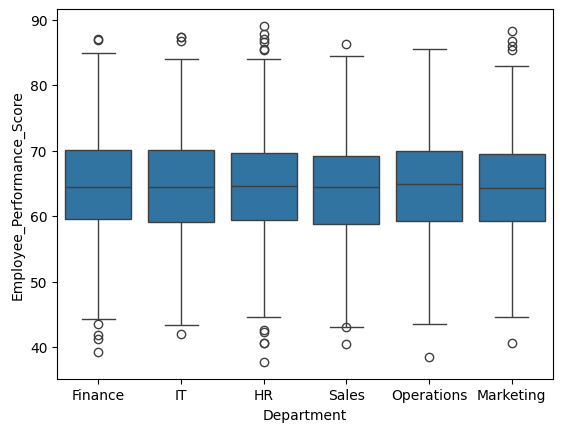

In [ ]:
#q9
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(
    x="Department",
    y="Employee_Performance_Score",
    data=df
)

<Axes: xlabel='Education_Level', ylabel='Employee_Performance_Score'>

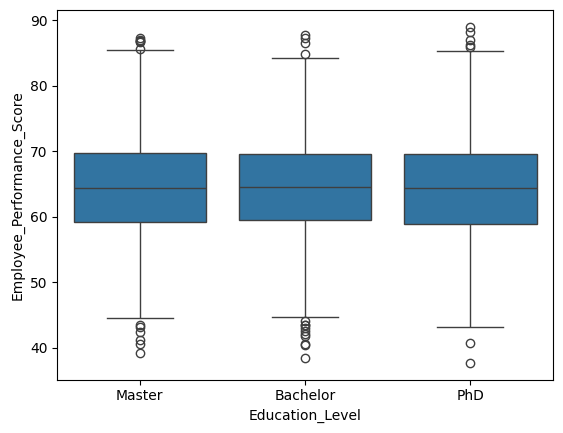

In [ ]:
#10
sns.boxplot(
    x="Education_Level",
    y="Employee_Performance_Score",
    data=df
)

In [ ]:
#11
df["Experience_Level"] = pd.cut(
    df["Experience_Years"],
    bins=[0,3,7,12,100],
    labels=[
        "Junior",
        "Mid",
        "Senior",
        "Expert"
    ]
)

In [ ]:
#12
df["Salary_Band"] = pd.qcut(
    df["Salary"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [ ]:
#13
df["Performance_Index"] = (
    df["Coding_Test_Score"]*0.5 +
    df["Communication_Score"]*0.3 +
    df["AI_Training_Hours"]*0.2
)

In [ ]:
#14
df["Coding_AI_Interaction"] = (
    df["Coding_Test_Score"] *
    df["AI_Training_Hours"]
)

In [ ]:
#15
columns_to_encode = [
    "Department",
    "Education_Level",
    "Gender",
    "Job_Role",
    "Experience_Years",
    "Salary",
    "Promotion_Last_3Y",
    "Attrition_Risk"
]
df_encoded = pd.get_dummies(
    df,
    columns=columns_to_encode,
    drop_first=True
)


Promotion_Last_3Y_Yes      0.245499
Experience_Level_Expert    0.242879
Education_Level_Master     0.239955
Gender_Other               0.239820
Education_Level_PhD        0.239780
Gender_Male                0.234007
Attrition_Risk_Medium      0.233918
Attrition_Risk_Low         0.230500
Salary_Band_Medium         0.229165
Salary_Band_High           0.217272
Department_Operations      0.208521
Department_Marketing       0.207947
Salary_Band_Very High      0.202493
Department_HR              0.198146
Department_Sales           0.194595
dtype: float64


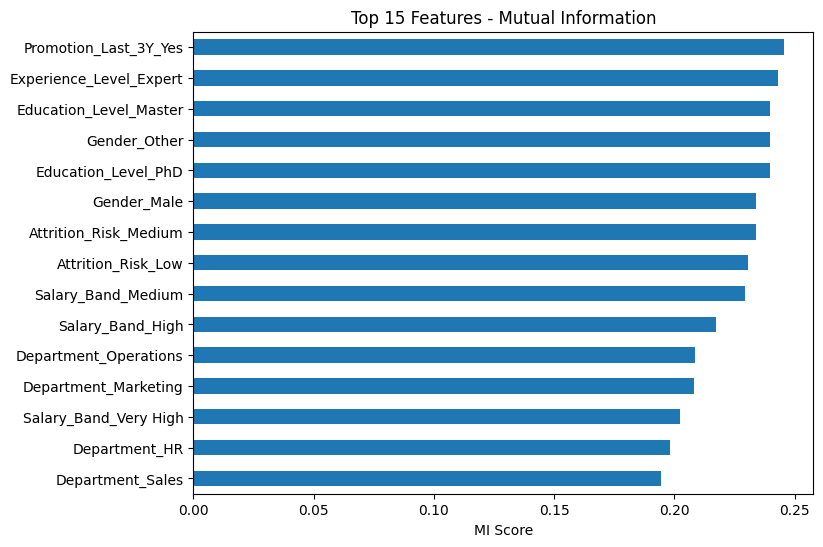

In [ ]:
#16

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)
#mi = mutual_info_regression(X,y)
from sklearn.feature_selection import mutual_info_regression
import pandas as pd
import matplotlib.pyplot as plt

target = "Employee_Performance_Score"

X = df_encoded.drop(columns=[target])
y = df_encoded[target]

mi = mutual_info_regression(X, y, random_state=42)

mi_scores = pd.Series(mi, index=X.columns)

top15_mi = mi_scores.sort_values(
    ascending=False
).head(15)

print(top15_mi)

plt.figure(figsize=(8,6))

top15_mi.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Features - Mutual Information")
plt.xlabel("MI Score")

plt.show()

In [ ]:
#17
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

rfe_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rfe = RFE(
    estimator=rfe_model,
    n_features_to_select=15
)

rfe.fit(X, y)

selected_features_rfe = X.columns[
    rfe.support_
]

print(selected_features_rfe)

In [28]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
rfe_model = RandomForestRegressor(
    n_estimators=20,
    random_state=42,
    n_jobs=-1
)

rfe = RFE(
    estimator=rfe_model,
    n_features_to_select=15,
    step=5
)

rfe.fit(X, y)

selected_features_rfe = X.columns[rfe.support_]

print(selected_features_rfe)

Index(['Employee_ID', 'Age', 'Certification_Count', 'Coding_Test_Score',
       'Communication_Score', 'Leadership_Score', 'Problem_Solving_Score',
       'Innovation_Score', 'Attendance_Percentage', 'Salary', 'Client_Rating',
       'Bug_Fix_Count', 'Deployment_Success_Rate', 'Manager_Rating',
       'Performance_Index'],
      dtype='object')


In [ ]:
print()

In [25]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

selector = SelectKBest(
    score_func=f_regression,
    k=15
)

selector.fit(X, y)

selected_features_kbest = X.columns[
    selector.get_support()
]

print(selected_features_kbest)

Index(['Certification_Count', 'Coding_Test_Score', 'Communication_Score',
       'Leadership_Score', 'Problem_Solving_Score', 'Innovation_Score',
       'Attendance_Percentage', 'Client_Rating', 'Deployment_Success_Rate',
       'Stress_Level', 'Performance_Index', 'Coding_AI_Interaction',
       'Gender_Other', 'Job_Role_QA Engineer', 'Salary_Band_High'],
      dtype='object')


In [29]:
#19
comparison = pd.DataFrame({
    "Mutual Information": top15_mi.index,
    "RFE": selected_features_rfe,
    "SelectKBest": selected_features_kbest
})

print(comparison)

         Mutual Information                      RFE              SelectKBest
0     Promotion_Last_3Y_Yes              Employee_ID      Certification_Count
1   Experience_Level_Expert                      Age        Coding_Test_Score
2    Education_Level_Master      Certification_Count      Communication_Score
3              Gender_Other        Coding_Test_Score         Leadership_Score
4       Education_Level_PhD      Communication_Score    Problem_Solving_Score
5               Gender_Male         Leadership_Score         Innovation_Score
6     Attrition_Risk_Medium    Problem_Solving_Score    Attendance_Percentage
7        Attrition_Risk_Low         Innovation_Score            Client_Rating
8        Salary_Band_Medium    Attendance_Percentage  Deployment_Success_Rate
9          Salary_Band_High                   Salary             Stress_Level
10    Department_Operations            Client_Rating        Performance_Index
11     Department_Marketing            Bug_Fix_Count    Coding_A

In [32]:
#20
final_features = list(
    set(top15_mi.index)
    | set(selected_features_rfe)
    | set(selected_features_kbest)
)
print("Final Features:")
print(final_features)

Final Features:
['Department_Sales', 'Bug_Fix_Count', 'Gender_Other', 'Experience_Level_Expert', 'Problem_Solving_Score', 'Attrition_Risk_Low', 'Coding_Test_Score', 'Certification_Count', 'Manager_Rating', 'Attrition_Risk_Medium', 'Department_HR', 'Performance_Index', 'Salary_Band_Medium', 'Education_Level_PhD', 'Coding_AI_Interaction', 'Communication_Score', 'Salary_Band_Very High', 'Job_Role_QA Engineer', 'Gender_Male', 'Leadership_Score', 'Salary', 'Deployment_Success_Rate', 'Department_Operations', 'Stress_Level', 'Client_Rating', 'Education_Level_Master', 'Promotion_Last_3Y_Yes', 'Salary_Band_High', 'Department_Marketing', 'Innovation_Score', 'Age', 'Employee_ID', 'Attendance_Percentage']


In [31]:
print(len(top15_mi))
print(len(selected_features_rfe))
print(len(selected_features_kbest))

15
15
15


In [33]:
#21
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df_encoded.drop("Employee_Performance_Score", axis=1)
y = df_encoded["Employee_Performance_Score"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

MAE: 3.928640840944385
RMSE: 4.937216296312096
R2: 0.5741732935897259


In [35]:
#22from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge = Ridge()
param_grid = {"alpha":[0.01,0.1,1,10,100]}
grid = GridSearchCV(ridge,param_grid,cv=5,scoring="r2")
grid.fit(X_train,y_train)
best_ridge = grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
print(grid.best_params_)
print(r2_score(y_test,y_pred_ridge))

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.42324e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.49044e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.44756e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.39013e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.38038e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

{'alpha': 100}
0.5766370567091789


In [36]:
#23
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train,y_train)
y_pred_lasso = lasso.predict(X_test)
print(r2_score(y_test,y_pred_lasso))

0.5802959601081301


In [37]:
#24
from sklearn.linear_model import ElasticNet
elastic = ElasticNet(alpha=0.1,l1_ratio=0.5)
elastic.fit(X_train,y_train)
y_pred_elastic = elastic.predict(X_test)
print(r2_score(y_test,y_pred_elastic))

0.5802655465610704


In [38]:
#25
coef_df = pd.DataFrame({
    "Feature":X.columns,
    "Linear":lr.coef_,
    "Ridge":best_ridge.coef_,
    "Lasso":lasso.coef_,
    "ElasticNet":elastic.coef_
})
coef_df.head()

,Feature,Linear,Ridge,Lasso,ElasticNet
0,Employee_ID,0.000055,0.000055,0.000053,0.000053
1,Age,-0.009367,-0.009507,-0.009013,-0.009446
2,Experience_Years,-0.011107,-0.004713,0.008297,0.008804
3,Certification_Count,0.239487,0.239328,0.234492,0.236472
4,AI_Training_Hours,-0.016936,-0.016913,0.000000,0.000000


In [39]:
#26
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt = dt.predict(X_test)
print(r2_score(y_test,y_pred_dt))

-0.0347204335944582


In [41]:
#27
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
print(r2_score(y_test,y_pred_rf))

0.5128808867274056


In [42]:
#28
from sklearn.ensemble import ExtraTreesRegressor

et = ExtraTreesRegressor(n_estimators=100,random_state=42)
et.fit(X_train,y_train)
y_pred_et = et.predict(X_test)
print(r2_score(y_test,y_pred_et))

0.5068521540068034


In [43]:
#29
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train,y_train)

y_pred_gb = gb.predict(X_test)

print(r2_score(y_test,y_pred_gb))

0.5587004585035273


In [45]:
#30
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42,n_estimators=100,learning_rate=0.1,max_depth=5)
xgb.fit(X_train,y_train)

y_pred_xgb = xgb.predict(X_test)

print(r2_score(y_test,y_pred_xgb))

0.5434515476226807


In [46]:
#31
results = pd.DataFrame({
    "Model":[
        "Linear",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "Gradient Boosting",
        "XGBoost"
    ],
    "R2":[
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_ridge),
        r2_score(y_test,y_pred_lasso),
        r2_score(y_test,y_pred_elastic),
        r2_score(y_test,y_pred_dt),
        r2_score(y_test,y_pred_rf),
        r2_score(y_test,y_pred_et),
        r2_score(y_test,y_pred_gb),
        r2_score(y_test,y_pred_xgb)
    ]
})
results.sort_values("R2",ascending=False)

,Model,R2
2,Lasso,0.580296
3,ElasticNet,0.580266
1,Ridge,0.576637
0,Linear,0.574173
7,Gradient Boosting,0.558700
8,XGBoost,0.543452
5,Random Forest,0.512881
6,Extra Trees,0.506852
4,Decision Tree,-0.034720


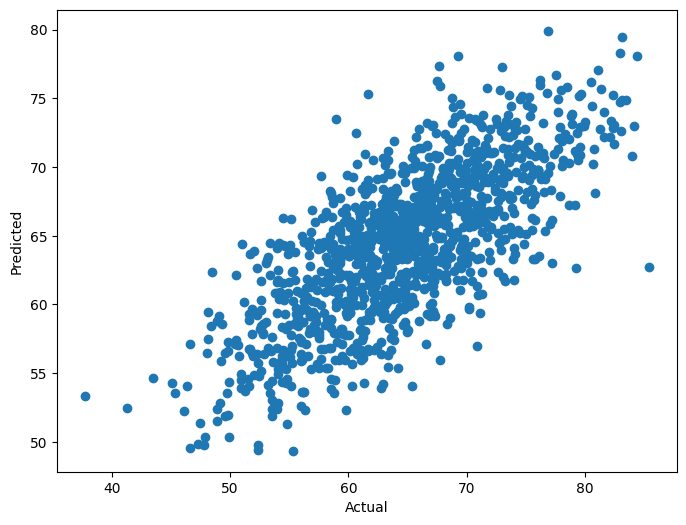

In [47]:
#32
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_xgb)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()

<Axes: xlabel='Employee_Performance_Score', ylabel='Count'>

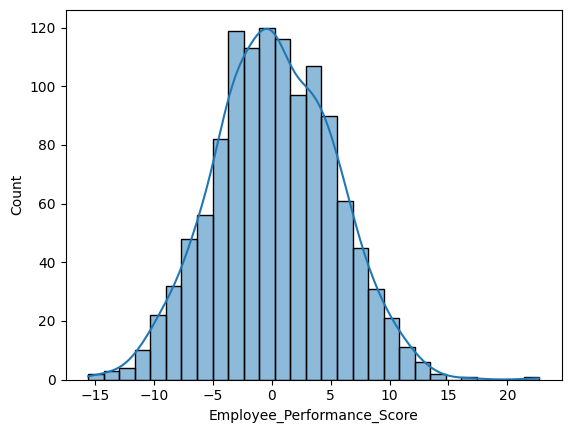

In [48]:
#33
residuals = y_test - y_pred_xgb
import seaborn as sns
sns.histplot(residuals,kde=True)

In [49]:
#34
print("Train R2:",xgb.score(X_train,y_train))
print("Test R2:",xgb.score(X_test,y_test))

Train R2: 0.7840033769607544
Test R2: 0.5434515476226807


In [50]:
#35
from sklearn.model_selection import cross_val_score
scores = cross_val_score(xgb,X,y,cv=10,scoring="r2")

print(scores.mean())
print(scores.std())

0.5304055154323578
0.017050474847708205


In [54]:
#36
param_grid = {"n_estimators":[4,4],"max_depth":[5,7,None]}
grid_rf = GridSearchCV(RandomForestRegressor(),param_grid,cv=5)
grid_rf.fit(X_train,y_train)
print(grid_rf.best_params_)

{'max_depth': 7, 'n_estimators': 4}


In [56]:
#37
from sklearn.model_selection import RandomizedSearchCV
params = {"n_estimators":[4,5,5],"max_depth":[3,5,7],"learning_rate":[0.01,0.05,0.1]}
random_search = RandomizedSearchCV(XGBRegressor(),params,n_iter=10,cv=5)
random_search.fit(X_train,y_train)
print(random_search.best_params_)

{'n_estimators': 5, 'max_depth': 7, 'learning_rate': 0.1}


In [57]:
#38
best_rf = grid_rf.best_estimator_
best_xgb = random_search.best_estimator_
print(r2_score(y_test,best_rf.predict(X_test)))
print(r2_score(y_test,best_xgb.predict(X_test)))

0.46046128215614535
0.2984734773635864


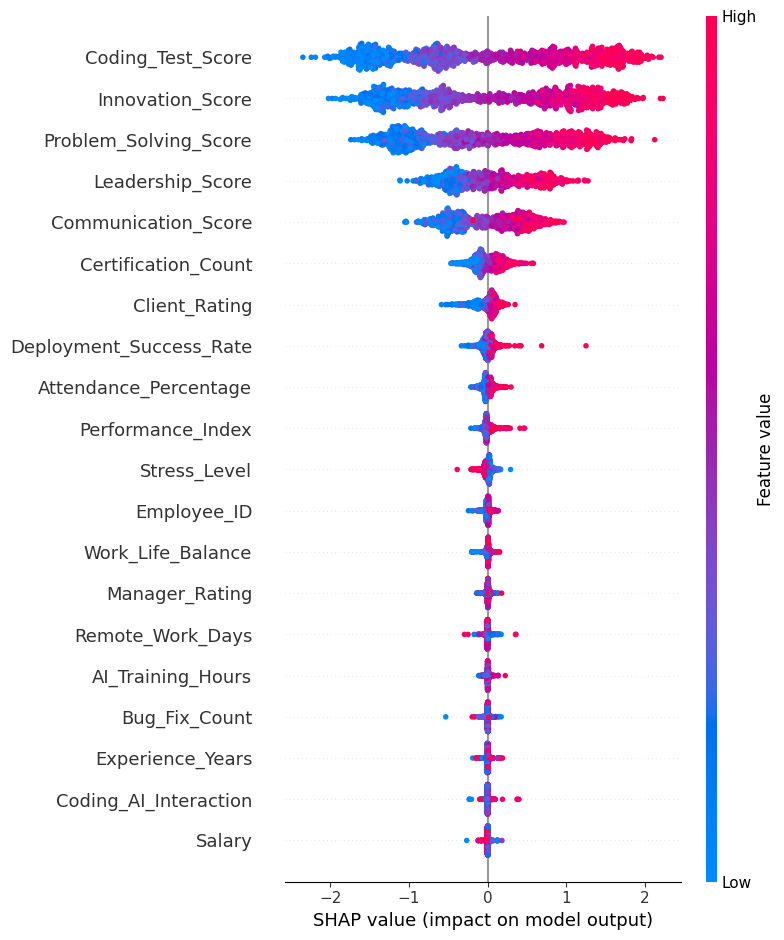

In [58]:
#39
import shap
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values,X_test)

In [59]:
#40
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest,f_regression
from sklearn.ensemble import RandomForestRegressor
pipeline = Pipeline([(
        "feature_selection",
        SelectKBest(
            f_regression,
            k=15
        )
    ),
    (
        "model",
        RandomForestRegressor(
            random_state=42
        )
    )
])

pipeline.fit(X_train,y_train)

Pipeline(steps=[('feature_selection',
                 SelectKBest(k=15,
                             score_func=<function f_regression at 0x7c068ccb00e0>)),
                ('model', RandomForestRegressor(random_state=42))])

In [60]:
#saving the above model
import joblib
joblib.dump(pipeline,"employee_performance_model.pkl")

['employee_performance_model.pkl']

In [61]:
#load
loaded_model = joblib.load("employee_performance_model.pkl")
